In [1]:
"""
SBI based posterior inference for alpha and rho parameters of the gamma distribution of rate variation across sites.
This script uses existing training data (features + true parameters) to train a neural network model that can predict alpha and rho from features.
1. Trains a neural network using sbi (NPE) to learn the posterior distribution of alpha and rho given the features.
2. present the results with the script visualize_posteriors.py, which will show how well the model can recover the true parameters on a test set and visualize the learned posterior distributions.
"""
from copyreg import pickle
from dataclasses import dataclass
import math
import random
import pickle
import pathlib
import torch
from sbi.utils import BoxUniform
from sbi.inference import NPE
from sbi.inference import simulate_for_sbi

from ete3 import Tree
import numpy as np

from msasim import protocol, simulator as sim
from msasim.msa import Msa
from msasim.distributions import ZipfDistribution
from msasim.constants import SITE_RATE_MODELS
from msasim.constants import MODEL_CODES

import prior
from features_calculator import calculate_all_features

@dataclass
class SimulationParams:
    """Parameters controlling the shape of simulated MSAs."""
    min_taxa: int = 20
    max_taxa: int = 200
    min_seq_length: int = 100
    max_seq_length: int = 500


def generate_random_tree(n_taxa: int, scale: float) -> Tree:
    """Generate a random ultrametric tree with n_taxa leaves."""

    tree = Tree()
    tree.populate(n_taxa, random_branches=True)
    for node in tree.traverse():
        if node.dist == 0:
            continue
        node.dist = np.random.exponential(scale=scale)
    return tree


def setup_sim(tree: Tree) -> sim.Simulator:
    """
    Setup the simulator for a given tree and seed.

    Args:
        tree: ete3.Tree object
        sim_seed: Seed for this simulation

    Returns:
        msasim.Simulator object
    """
    newick_string = tree.write(format=1)
    simulation_protocol = protocol.SimProtocol(newick_string)
    # indel model parameters based on mammalian rates from https://doi.org/10.1093/bioinformatics/btaf686
    simulation_protocol.set_insertion_rates(0.007)
    simulation_protocol.set_deletion_rates(0.035)
    simulation_protocol.set_insertion_length_distributions(ZipfDistribution(p=1.53, truncation=50))
    simulation_protocol.set_deletion_length_distributions(ZipfDistribution(p=1.11, truncation=50))
    simulation_protocol.set_site_rate_model(SITE_RATE_MODELS.INDEL_AWARE)
    simulator = sim.Simulator(simulation_protocol, simulation_type=sim.SIMULATION_TYPE.PROTEIN)
    return simulator


prior_dist = BoxUniform(
    low=torch.tensor([prior.ALPHA_RANGE[0], prior.RHO_RANGE[0], math.log10(prior.TREE_SCALE_RANGE[0])]),
    high=torch.tensor([prior.ALPHA_RANGE[1], prior.RHO_RANGE[1], math.log10(prior.TREE_SCALE_RANGE[1])])
)    


def simulate(theta: torch.Tensor):
    """

    Simulate a single an MSA based on a random tree.

    Args:
        theta: torch.Tensor of shape (3,) containing the parameters (alpha, rho, tree_scale) for this simulation
    Returns:
        tuple: (sequences, true_alpha, true_rho, true_tree_scale)
            sequences: list of sequence strings
            true_alpha: float
            true_rho: float
            true_tree_scale: float
    """

    params = SimulationParams()  # Use default simulation parameters for taxa and sequence length ranges
    # go through all params in tensor and simulate for each then return all features as tensor
    # loop through each row of theta and simulate an MSA for each set of parameters, then save features for each MSA and return as tensor
    features_list = []
    for i in range(theta.shape[0]):
        true_alpha, true_rho, true_tree_scale = theta[i].tolist()
        # convert log10 tree_scale back to linear scale
        true_tree_scale = 10 ** true_tree_scale


        n_taxa = random.randint(params.min_taxa, params.max_taxa)
        simulator = setup_sim(generate_random_tree(n_taxa=n_taxa, scale=true_tree_scale))  # Example simulator for testing

        seq_length = random.randint(params.min_seq_length, params.max_seq_length)

        simulator.protocol.set_sequence_size(seq_length)
        simulator.set_replacement_model(
            model=MODEL_CODES.WAG,
            gamma_parameters_alpha=true_alpha,
            gamma_parameters_categories=8,
            site_rate_correlation=true_rho
        )

        msa: Msa = simulator()
        sequences = [msa.get_msa_row(i).split("\n")[1] for i in range(msa.get_num_sequences())]

        stats = calculate_all_features(sequences)
        features_list.append(torch.tensor(list(stats.values()), dtype=torch.float32))

    # return tensor of features for this simulation
    return torch.stack(features_list)

/home/pupkolab/envs/sparta/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
theta_0 = prior_dist.sample((1,))
feature_0 = simulate(theta_0)

# print theta and features for this example simulation
print("Sampled parameters (alpha, rho, tree_scale):", theta_0)


Sampled parameters (alpha, rho, tree_scale): tensor([[ 2.1241,  0.9006, -1.1642]])


In [3]:

# print("Calculated features:", feature_0)
num_simulations = 20000
thetas, features = simulate_for_sbi(simulate, prior_dist, 
                                    num_simulations=num_simulations,
                                    num_workers=7)  # Simulate MSAs and calculate features for each

inference = NPE(prior=prior_dist)


inference.append_simulations(thetas, features).train()

posterior = inference.build_posterior()
print(posterior)

x_obs = feature_0
samples = posterior.sample((1000,), x=x_obs)

# mean and std of samples
print("Posterior samples mean:", samples.mean(dim=0))
print("Posterior samples std:", samples.std(dim=0))

100%|██████████| 20000/20000 [18:29<00:00, 18.02it/s]
/home/pupkolab/envs/sparta/lib/python3.10/site-packages/sbi/inference/trainers/npe/npe_base.py:196: UserWarning: Data has extreme outliers in dimension(s) [4, 5, 7, 17, 27, 29] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 95 epochs.Posterior p(θ|x) of type DirectPosterior. It samples the posterior network and rejects samples that
            lie outside of the prior bounds.


1052it [00:00, 43266.11it/s]            

Posterior samples mean: tensor([ 2.8056,  0.8793, -1.2671])
Posterior samples std: tensor([0.8469, 0.0590, 0.1228])


In [ ]:
new_thetas, new_features = simulate_for_sbi(simulate, prior_dist,
                                             num_simulations=30000,
                                             num_workers=7)


100%|██████████| 30000/30000 [28:15<00:00, 17.70it/s]
/home/pupkolab/envs/sparta/lib/python3.10/site-packages/sbi/inference/trainers/npe/npe_base.py:196: UserWarning: Data has extreme outliers in dimension(s) [4, 5, 7, 17, 27, 29] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)


ValueError: This neural network has already been trained. If you want to continue training without adding new simulations, set resume_training=True. If you appended new simulations, you must either provide a proposal in append_simulations(), or set force_first_round_loss=True for simulations drawn from the prior. Warning: Setting force_first_round_loss=True with simulations not drawn from the prior will produce the proposal posterior instead of the true posterior, which is typically more narrow.

In [10]:
inference.append_simulations(new_thetas, new_features).train(force_first_round_loss=True)
posterior = inference.build_posterior()

 Neural network successfully converged after 94 epochs.

In [11]:
# test accuracy of model on a new simulation
theta_test = prior_dist.sample((100,))
features_test = simulate(theta_test)
posterior_samples_test = posterior.sample_batched((1000,), x=features_test)

# compute R^2 between true parameters (theta_test) and posterior samples mean
# fore each parameter (alpha, rho, tree_scale)

r2_alpha = 1 - torch.sum((posterior_samples_test[:, :, 0].mean(dim=0) - theta_test[:, 0]) ** 2) / torch.sum((theta_test[:, 0] - theta_test[:, 0].mean()) ** 2)
r2_rho = 1 - torch.sum((posterior_samples_test[:, :, 1].mean(dim=0) - theta_test[:, 1]) ** 2) / torch.sum((theta_test[:, 1] - theta_test[:, 1].mean()) ** 2)    
r2_tree_scale = 1 - torch.sum((posterior_samples_test[:, :, 2].mean(dim=0) - theta_test[:, 2]) ** 2) / torch.sum((theta_test[:, 2] - theta_test[:, 2].mean()) ** 2)
print("Test set R^2 (alpha):", r2_alpha)
print("Test set R^2 (rho):", r2_rho)
print("Test set R^2 (tree_scale):", r2_tree_scale)


/tmp/ipykernel_187190/151003810.py:4: UserWarning: Capping max_sampling_batch_size from 10000 to 1000 to avoid excessive memory usage.
  posterior_samples_test = posterior.sample_batched((1000,), x=features_test)
Drawing 1000 samples for 100 observations: 1181it [00:01, 657.10it/s]                         

Test set R^2 (alpha): tensor(0.7785)
Test set R^2 (rho): tensor(0.6978)
Test set R^2 (tree_scale): tensor(0.9461)


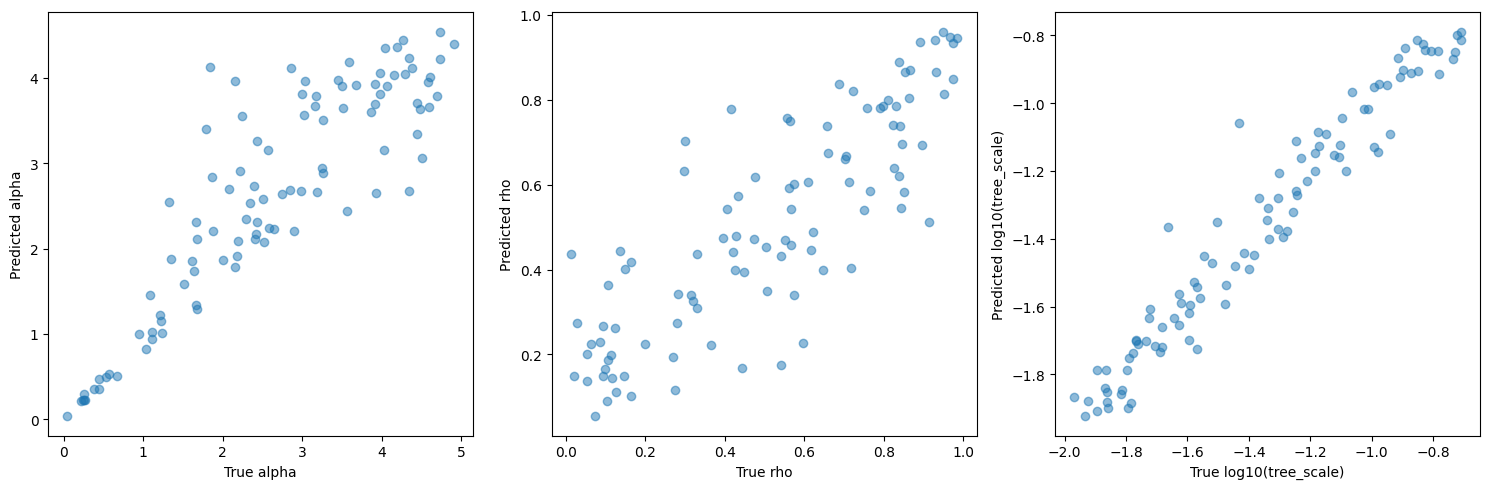

In [12]:
# scatter plot of true vs predicted parameters for test set
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.scatter(theta_test[:, 0].numpy(), posterior_samples_test[:, :, 0].mean(dim=0).numpy(), alpha=0.5)
plt.xlabel("True alpha")
plt.ylabel("Predicted alpha")
plt.subplot(1, 3, 2)
plt.scatter(theta_test[:, 1].numpy(), posterior_samples_test[:, :, 1].mean(dim=0).numpy(), alpha=0.5)
plt.xlabel("True rho")
plt.ylabel("Predicted rho")
plt.subplot(1, 3, 3)
plt.scatter(theta_test[:, 2].numpy(), posterior_samples_test[:, :, 2].mean(dim=0).numpy(), alpha=0.5)
plt.xlabel("True log10(tree_scale)")
plt.ylabel("Predicted log10(tree_scale)")
plt.tight_layout()
plt.show()

[[ 2.25863173e-01  9.31589765e-03  8.58684806e-01]
 [-1.38089673e-01  2.36792059e-03  8.88949386e-01]
 [-2.40926727e-01  1.45464485e-03  8.64300724e-01]
 [-6.32731841e-02  4.88331338e-01  6.10285350e-01]
 [-5.11829664e-01  3.00958791e-03 -5.58550227e-01]
 [-2.50192544e-01  2.98844568e-02 -3.28562782e-01]
 [-6.22471269e-01 -4.52024379e-04  3.15138522e-02]
 [ 1.23098119e-01  1.31159007e-02  1.76589713e-01]
 [-2.83982011e-01 -1.19563153e-02 -8.31029805e-01]
 [ 1.97015386e-02 -2.15240844e-02 -6.70078300e-01]
 [ 1.30991170e-01 -1.39211442e-02 -6.34909331e-02]
 [ 3.36648722e-01 -5.16642395e-03  8.70250130e-02]
 [ 3.95131357e-01  1.03993512e-02  4.01406912e-01]
 [ 3.28242840e-01  1.68528924e-02  6.26389376e-01]
 [ 2.25407105e-01  1.81833946e-02  7.30649583e-01]
 [ 6.82463226e-02  1.40137877e-02  7.48096698e-01]
 [-1.49612427e-01  1.10742002e-02  6.62068862e-01]
 [-3.19729541e-01  4.11441307e-03  3.72943335e-01]
 [ 2.31199692e-02  5.03738138e-01  5.44179016e-01]
 [ 6.10135991e-02  4.70749288e-

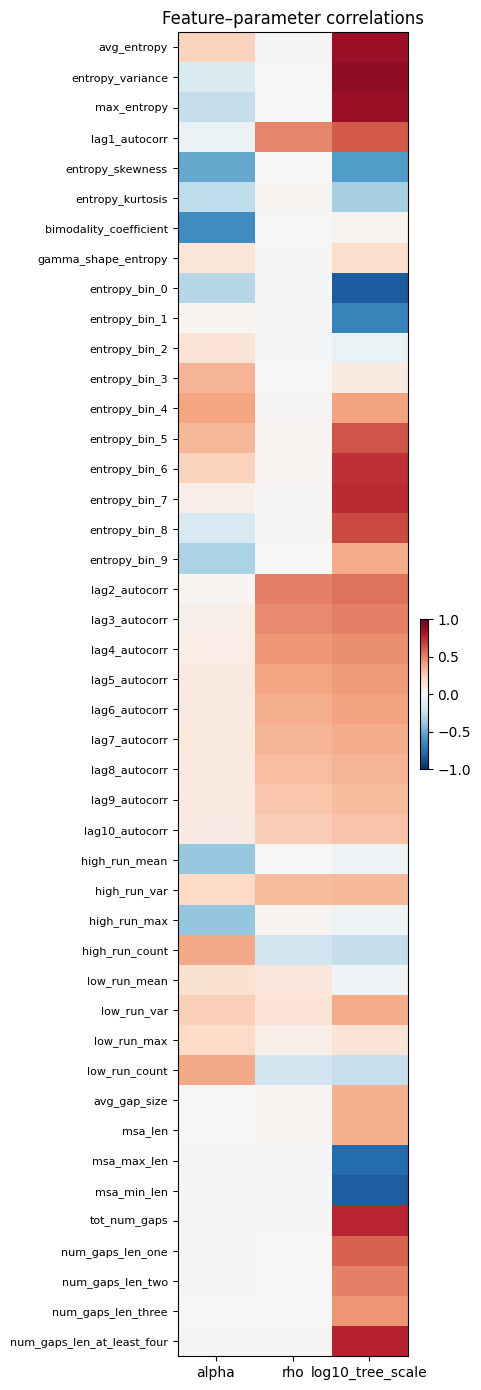

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

FEATURE_NAMES = [
    'avg_entropy', 'entropy_variance', 'max_entropy', 'lag1_autocorr',
    'entropy_skewness', 'entropy_kurtosis', 'bimodality_coefficient', 'gamma_shape_entropy',
    'entropy_bin_0', 'entropy_bin_1', 'entropy_bin_2', 'entropy_bin_3', 'entropy_bin_4',
    'entropy_bin_5', 'entropy_bin_6', 'entropy_bin_7', 'entropy_bin_8', 'entropy_bin_9',
    'lag2_autocorr', 'lag3_autocorr', 'lag4_autocorr', 'lag5_autocorr', 'lag6_autocorr',
    'lag7_autocorr', 'lag8_autocorr', 'lag9_autocorr', 'lag10_autocorr',
    'high_run_mean', 'high_run_var', 'high_run_max', 'high_run_count',
    'low_run_mean',  'low_run_var',  'low_run_max',  'low_run_count',
    'avg_gap_size', 'msa_len', 'msa_max_len', 'msa_min_len', 'tot_num_gaps',
    'num_gaps_len_one', 'num_gaps_len_two', 'num_gaps_len_three', 'num_gaps_len_at_least_four',
]
PARAM_NAMES = ['alpha', 'rho', 'log10_tree_scale']

F = features.numpy()
T = thetas.numpy()
# add new features and parameters from new_thetas and new_features
F = np.concatenate([F, new_features.numpy()], axis=0)
T = np.concatenate([T, new_thetas.numpy()], axis=0)

corr = np.array([[np.corrcoef(F[:, i], T[:, j])[0, 1]
                  for j in range(3)]
                 for i in range(len(FEATURE_NAMES))])
print(corr)
fig, ax = plt.subplots(figsize=(5, 14))
im = ax.imshow(corr, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(3)); ax.set_xticklabels(PARAM_NAMES)
ax.set_yticks(range(len(FEATURE_NAMES))); ax.set_yticklabels(FEATURE_NAMES, fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.03)
plt.title('Feature–parameter correlations')
plt.tight_layout()
plt.show()

tensor([ 2.4182,  0.4725, -1.3452])